# [LAB-13] 3. 분해 시계열

## #01. 준비작업

In [1]:
from jussam import load_data
from helper import *

from pandas import DataFrame
import numpy as np
import seaborn as sb

# 시계열 분해
from statsmodels.tsa.seasonal import seasonal_decompose

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기 + 시계열 인덱스 설정

In [2]:
origin = load_data('air_passengers')

# 월단위 데이터임을 알림 --> freq="MS" (Month Start)
df = my_ts.set_index(origin, "Month", freq="MS")
print("인덱스 간격(freq):", df.index.freqstr)
df.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
인덱스 간격(freq): MS


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## #02. 분해 시계열 (Decomposition)

### 1. 어느 모델을 쓸 것인가? - 데이터로 판단하기

- **연도별 변동폭이 커지는지 확인**하면 된다.
  - **1단원에서 만든 `report_variation()`함수가 이 질문에도 그대로 답한다.**


In [3]:
# 기간 단위(기본 freq="YE" → 연 단위)로 묶어 평균 · 표준편차 · 변동계수를 계산한다.
# 변동계수 = 표준편차 / 평균. 승법이면 이 값이 일정하다.
# 판정 문장은 함수가 출력하고, 표는 반환되므로 마지막 줄에 놓아 화면에 띄운다.
my_ts.report_variation(df, "Passengers", freq="YE")

표준편차 최대/최소 : 5.67배
변동계수 최대/최소 : 1.56배
판정: 변동폭이 수준에 비례한다 → 로그변환 권장 / 승법(multiplicative) 모델


,평균,표준편차,변동계수
기간,,,
1949-12-31,126.667,13.720,0.108
1950-12-31,139.667,19.071,0.137
1951-12-31,170.167,18.438,0.108
1952-12-31,197.000,22.966,0.117
1953-12-31,225.000,28.467,0.127
1954-12-31,238.917,34.924,0.146
1955-12-31,284.000,42.140,0.148
1956-12-31,328.250,47.862,0.146
1957-12-31,368.417,57.891,0.157


#### 💡 인사이트

| 지표 | 최대/최소 비율 | 의미 |
|---|---|---|
| 표준편차 | **5.67배** | 절대적인 변동폭이 계속 커진다 → 가법 모델 부적합 |
| **변동계수** | **1.56배** | 평균 대비 변동폭은 거의 일정하다 → **승법 모델 적합** |

- 판정 문장이 **"로그변환 권장 / 승법(multiplicative) 모델"** 로 두 결론을 함께 알려 준다.
- 인덱스가 연도(1949)가 아니라 **구간의 끝 날짜(1949-12-31)** 인 것은
  `Grouper(freq="YE")` 가 연말 기준으로 잘라 묶기 때문이다.

> 🔑 **판단 규칙**
> - 표준편차가 일정 → **가법 모델**
> - 표준편차는 커지는데 **변동계수(표준편차/평균)가 일정** → **승법 모델**
>
> 이 데이터는 후자이므로 **승법 모델**을 쓴다.

### 2. 분해 시계열 생성

- statsmodels의 `seasonal_decompose()`가 세 성분을 한 번에 계산해 준다.
  - model 파라미터에 **가법모델(additive) 또는 승법모델(multiplicative)** 여부를 를 지정해야 한다.

> ⚠️ **분해는 차분하기 전의 원본으로 하는 것이 원칙이다.**
> 차분은 추세와 계절성을 지우는 작업인데, 분해는 그 추세와 계절성을 보려는 것이기 때문이다.

> ⚠️ **`trend`와 `resid`의 앞뒤 6개월은 결측치다.**
> 추세를 12개월 이동평균으로 계산하므로 양 끝에서는 평균 낼 값이 부족하기 때문이다.
> `sd.dropna()`로 확인하면 144개월 중 **132개월**만 남는다.

In [4]:
# 분해 수행 --> 분해할 시계열, 모델 유형(승법/가법), 계절 주기(period)
# 반환값은 `observed` · `trend` · `seasonal` · `resid` 네 개의 Series를 속성으로 가진 객체
result = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)

# 비교와 저장이 편하도록 데이터프레임 하나로 묶어서 사용 (인덱스는 원본과 동일)
sd = DataFrame({
    "original": result.observed,     # 원본 시계열
    "trend": result.trend,           # 추세 성분 (장기적 방향)
    "seasonal": result.seasonal,     # 계절 성분 (주기적 반복)
    "resid": result.resid,           # 잔차 성분 (설명되지 않는 변동)
})

sd.dropna()

,original,trend,seasonal,resid
Month,,,,
1949-07-01,148.000,126.792,1.227,0.952
1949-08-01,148.000,127.250,1.220,0.953
1949-09-01,136.000,127.958,1.060,1.002
1949-10-01,119.000,128.583,0.922,1.004
1949-11-01,104.000,129.000,0.801,1.006
...,...,...,...,...
1960-02-01,391.000,461.375,0.884,0.959
1960-03-01,419.000,465.208,1.007,0.894
1960-04-01,461.000,469.333,0.976,1.006


### 3. 분해된 성분 시각화

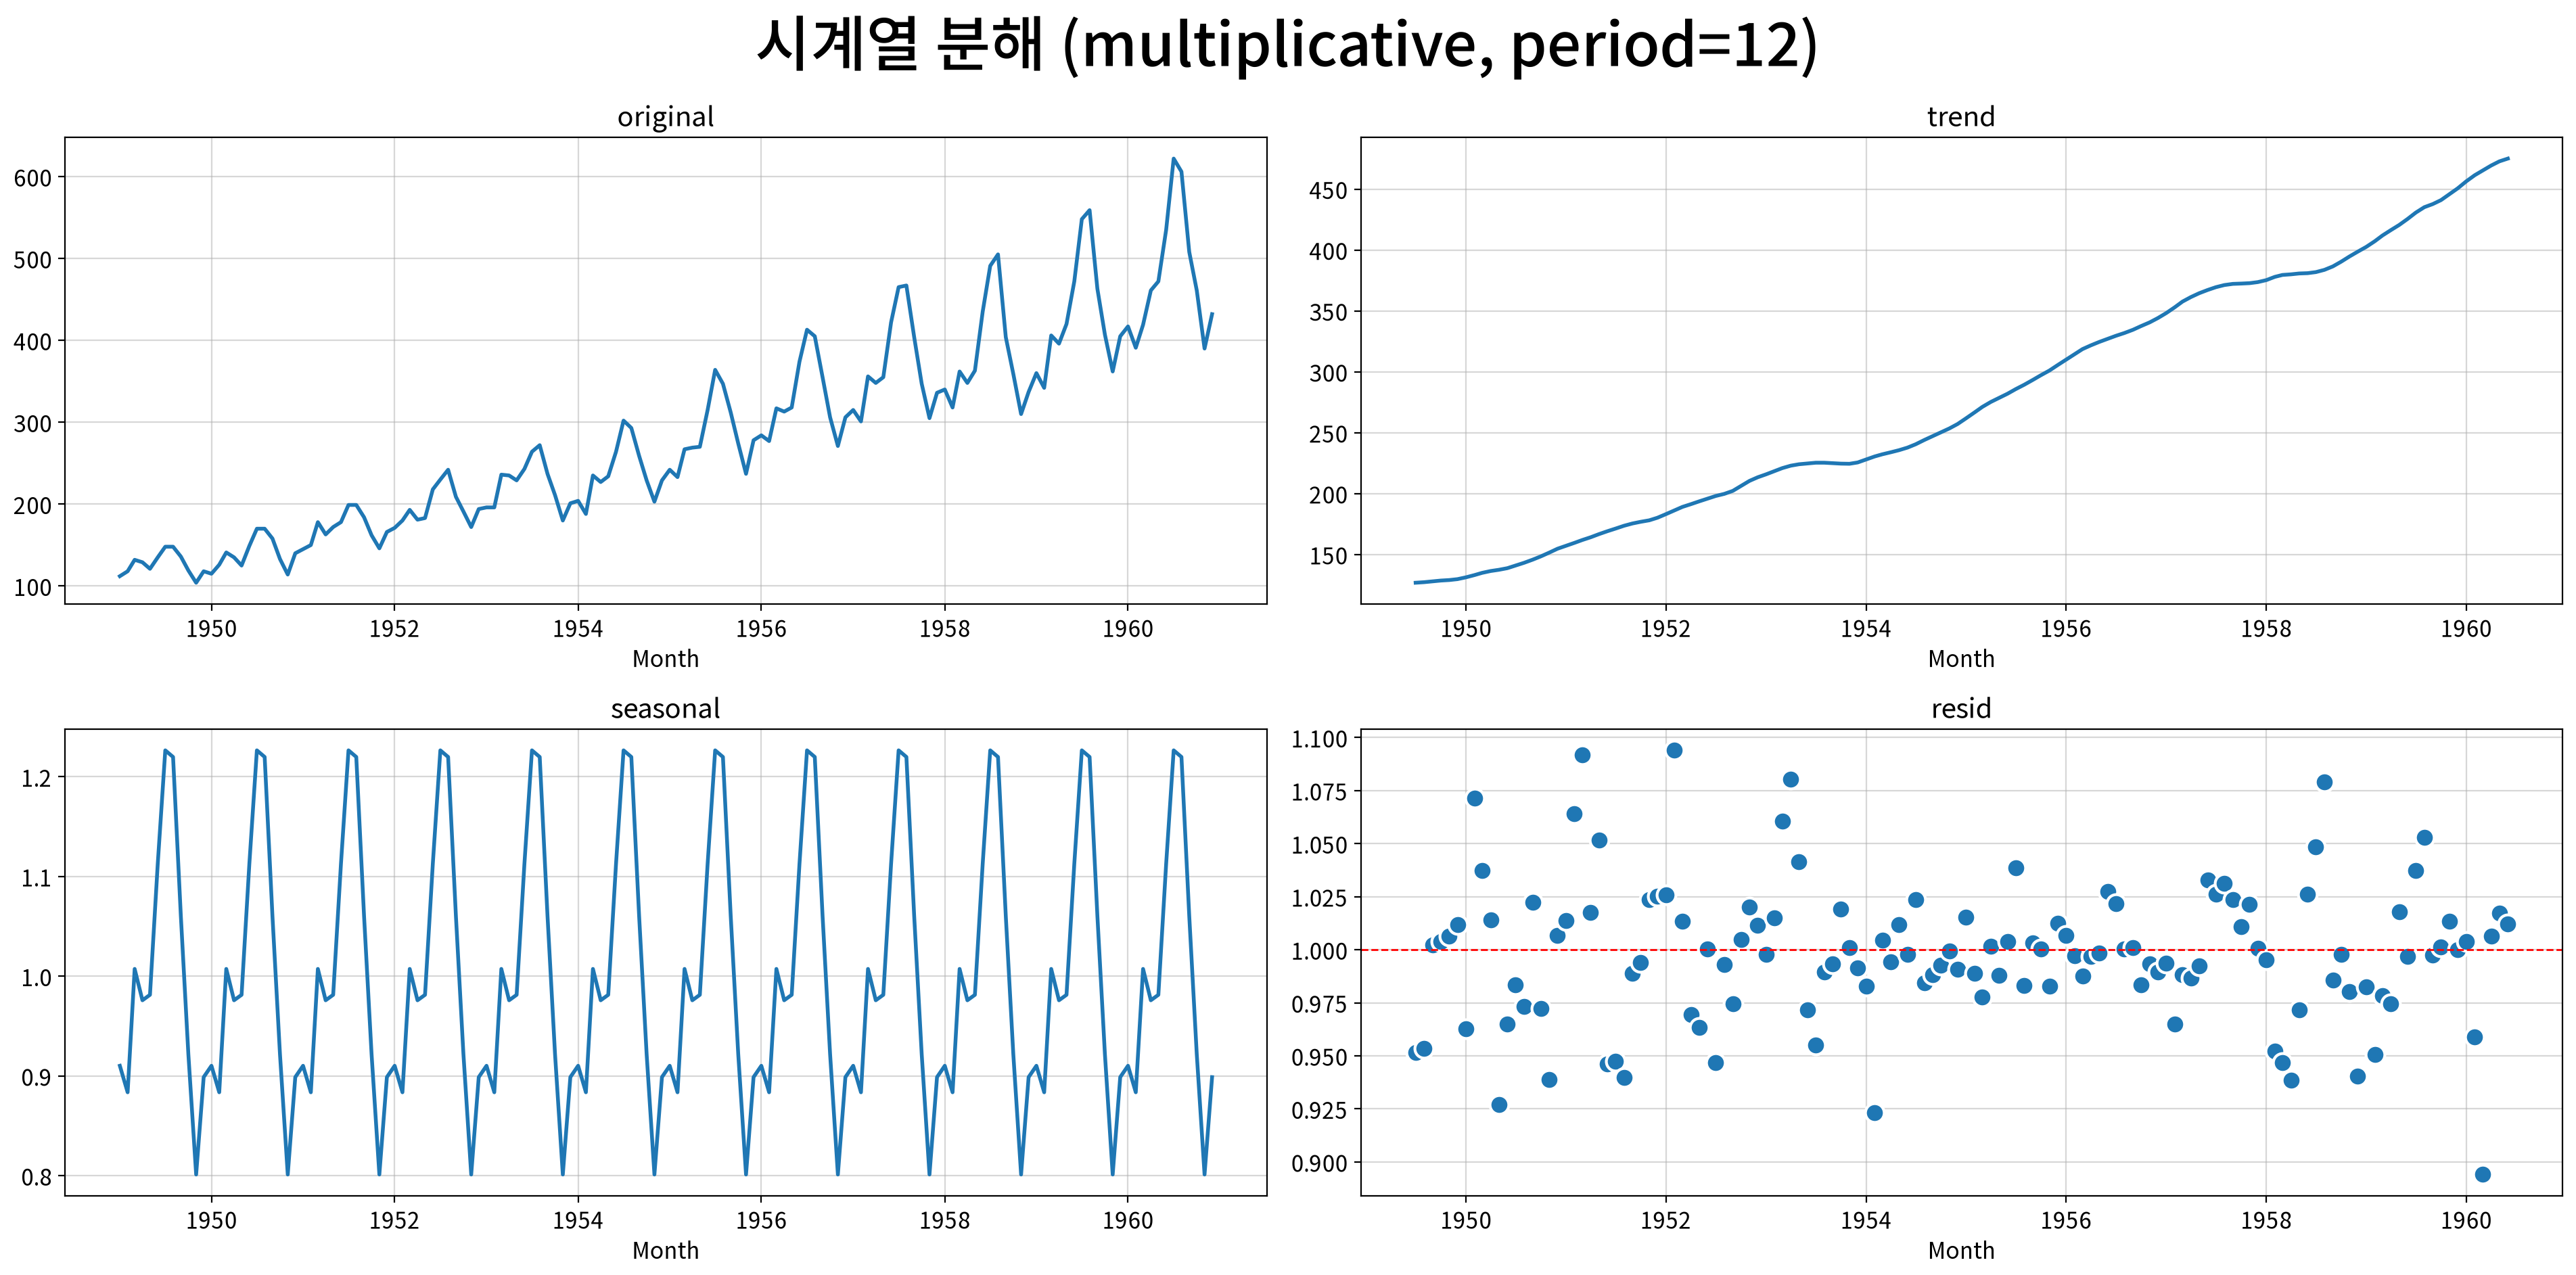

In [5]:
# 성분별로 한 단씩, 4단 그래프로 그린다
fig, ax = my_plot.init(rows=2, cols=2, width=960, height=480,
                       title="시계열 분해 (multiplicative, period=12)")

for i, col in enumerate(sd.columns):
    if col == "resid":
        # 잔차는 불규칙하므로 점으로 그려야 남은 패턴이 보인다
        my_plot.scatterplot(data=sd, x=sd.index, y=col, ax=ax[i])
    else:
        my_plot.lineplot(x=sd.index, y=sd[col], ax=ax[i])

    ax[i].set_title(col)
    ax[i].set_ylabel("")

# 승법 모델의 잔차 기준선은 1 (가법 모델이면 0)
ax[3].axhline(1, color="red", linestyle="--", linewidth=1)

my_plot.show()

#### 💡 인사이트

| 성분 | 관찰 결과 | 해석 |
|---|---|---|
| **trend** | 1949년 7월 **126.8**에서 1960년 6월 **475.0**까지 매끄럽게 우상향 | 계절 요동이 완전히 제거된 순수한 성장 곡선 |
| **seasonal** | **1년 주기로 완전히 동일한 모양이 반복** | 7~8월에 1.22배, 11월에 0.80배 수준 |
| **resid** | **0.894 ~ 1.094 범위**에서 1.0 주변에 무작위로 흩어짐 (평균 0.998) | 추세와 계절로 설명되지 않는 부분이 ±10% 이내 |

- 승법 모델이므로 계절 성분은 **배수**로 읽는다.
  `seasonal = 1.227` 은 "그 달은 추세선보다 **22.7% 높다**"는 뜻이다.
- 잔차가 1 주변에 몰려 있다는 것은 **분해가 잘 되었다**는 신호다.
  잔차에 뚜렷한 패턴이 남아 있다면 주기를 잘못 잡았거나 모델 선택이 틀린 것이다.

## #03. 분해 시계열의 특성

### 1. 추세(Trend)와 이동평균 비교(1) - 이동평균 구하기

- 앞의 내용에서 추세는 **이동평균(창 = 계절 주기)** 으로 계산한다고 했다.
- 2단원에서 만든 `my_ts.plot_rolling()` 으로 직접 확인해 보자.

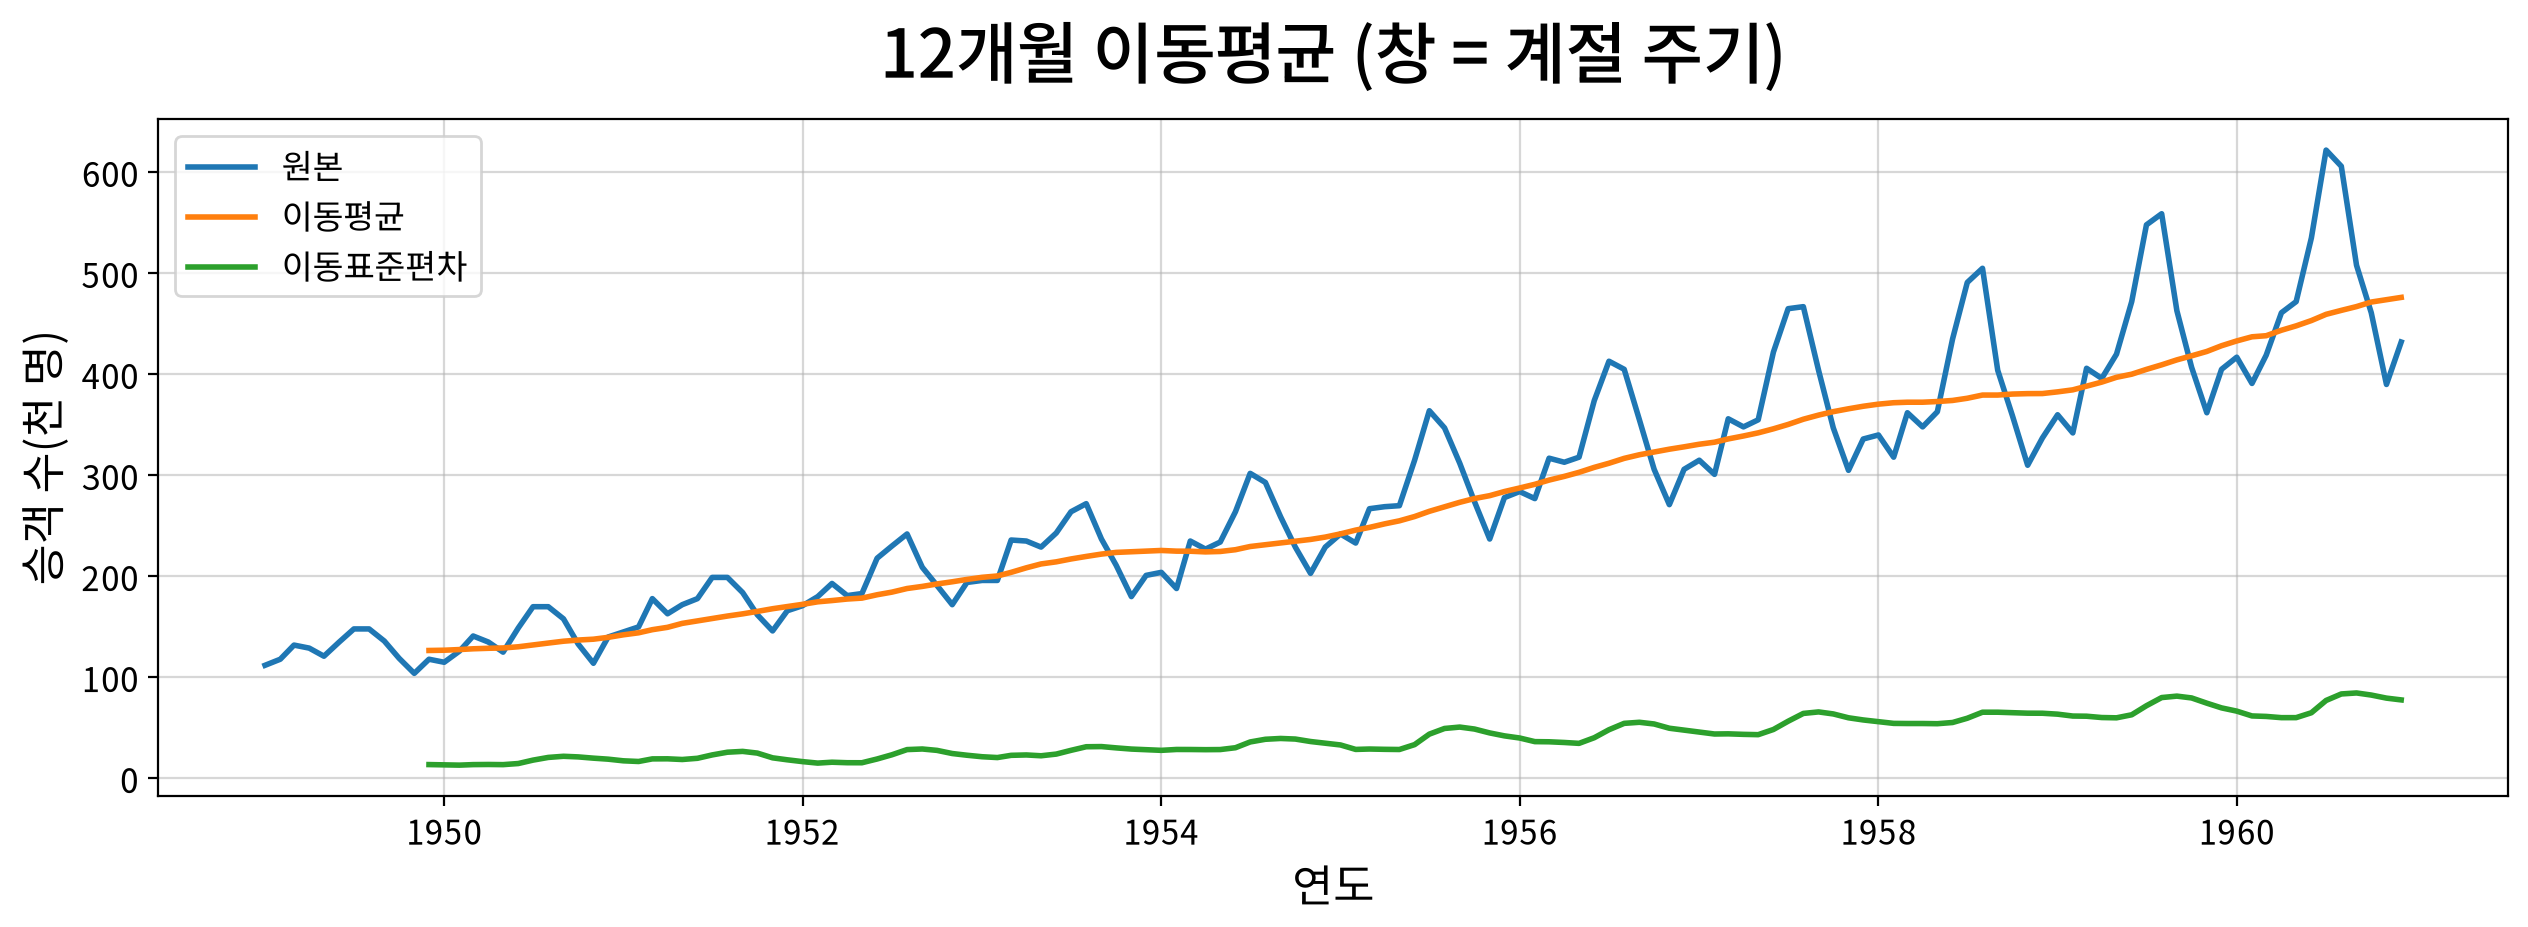

,원본,이동평균,이동표준편차
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,NaN,NaN
1949-04-01,129,NaN,NaN
1949-05-01,121,NaN,NaN


In [6]:
# 2단원에서 만든 함수로 12개월 이동평균을 구한다.
# --> 리턴값이 이동평균이 계산된 데이터프레임
rolling = my_ts.plot_rolling(df, 12, "Passengers",
                             title="12개월 이동평균 (창 = 계절 주기)",
                             xlabel="연도", ylabel="승객 수(천 명)")
rolling.head()

### 2. 추세(Trend)와 이동평균 비교(2) - 추세와 이동평균 상관계수 확인

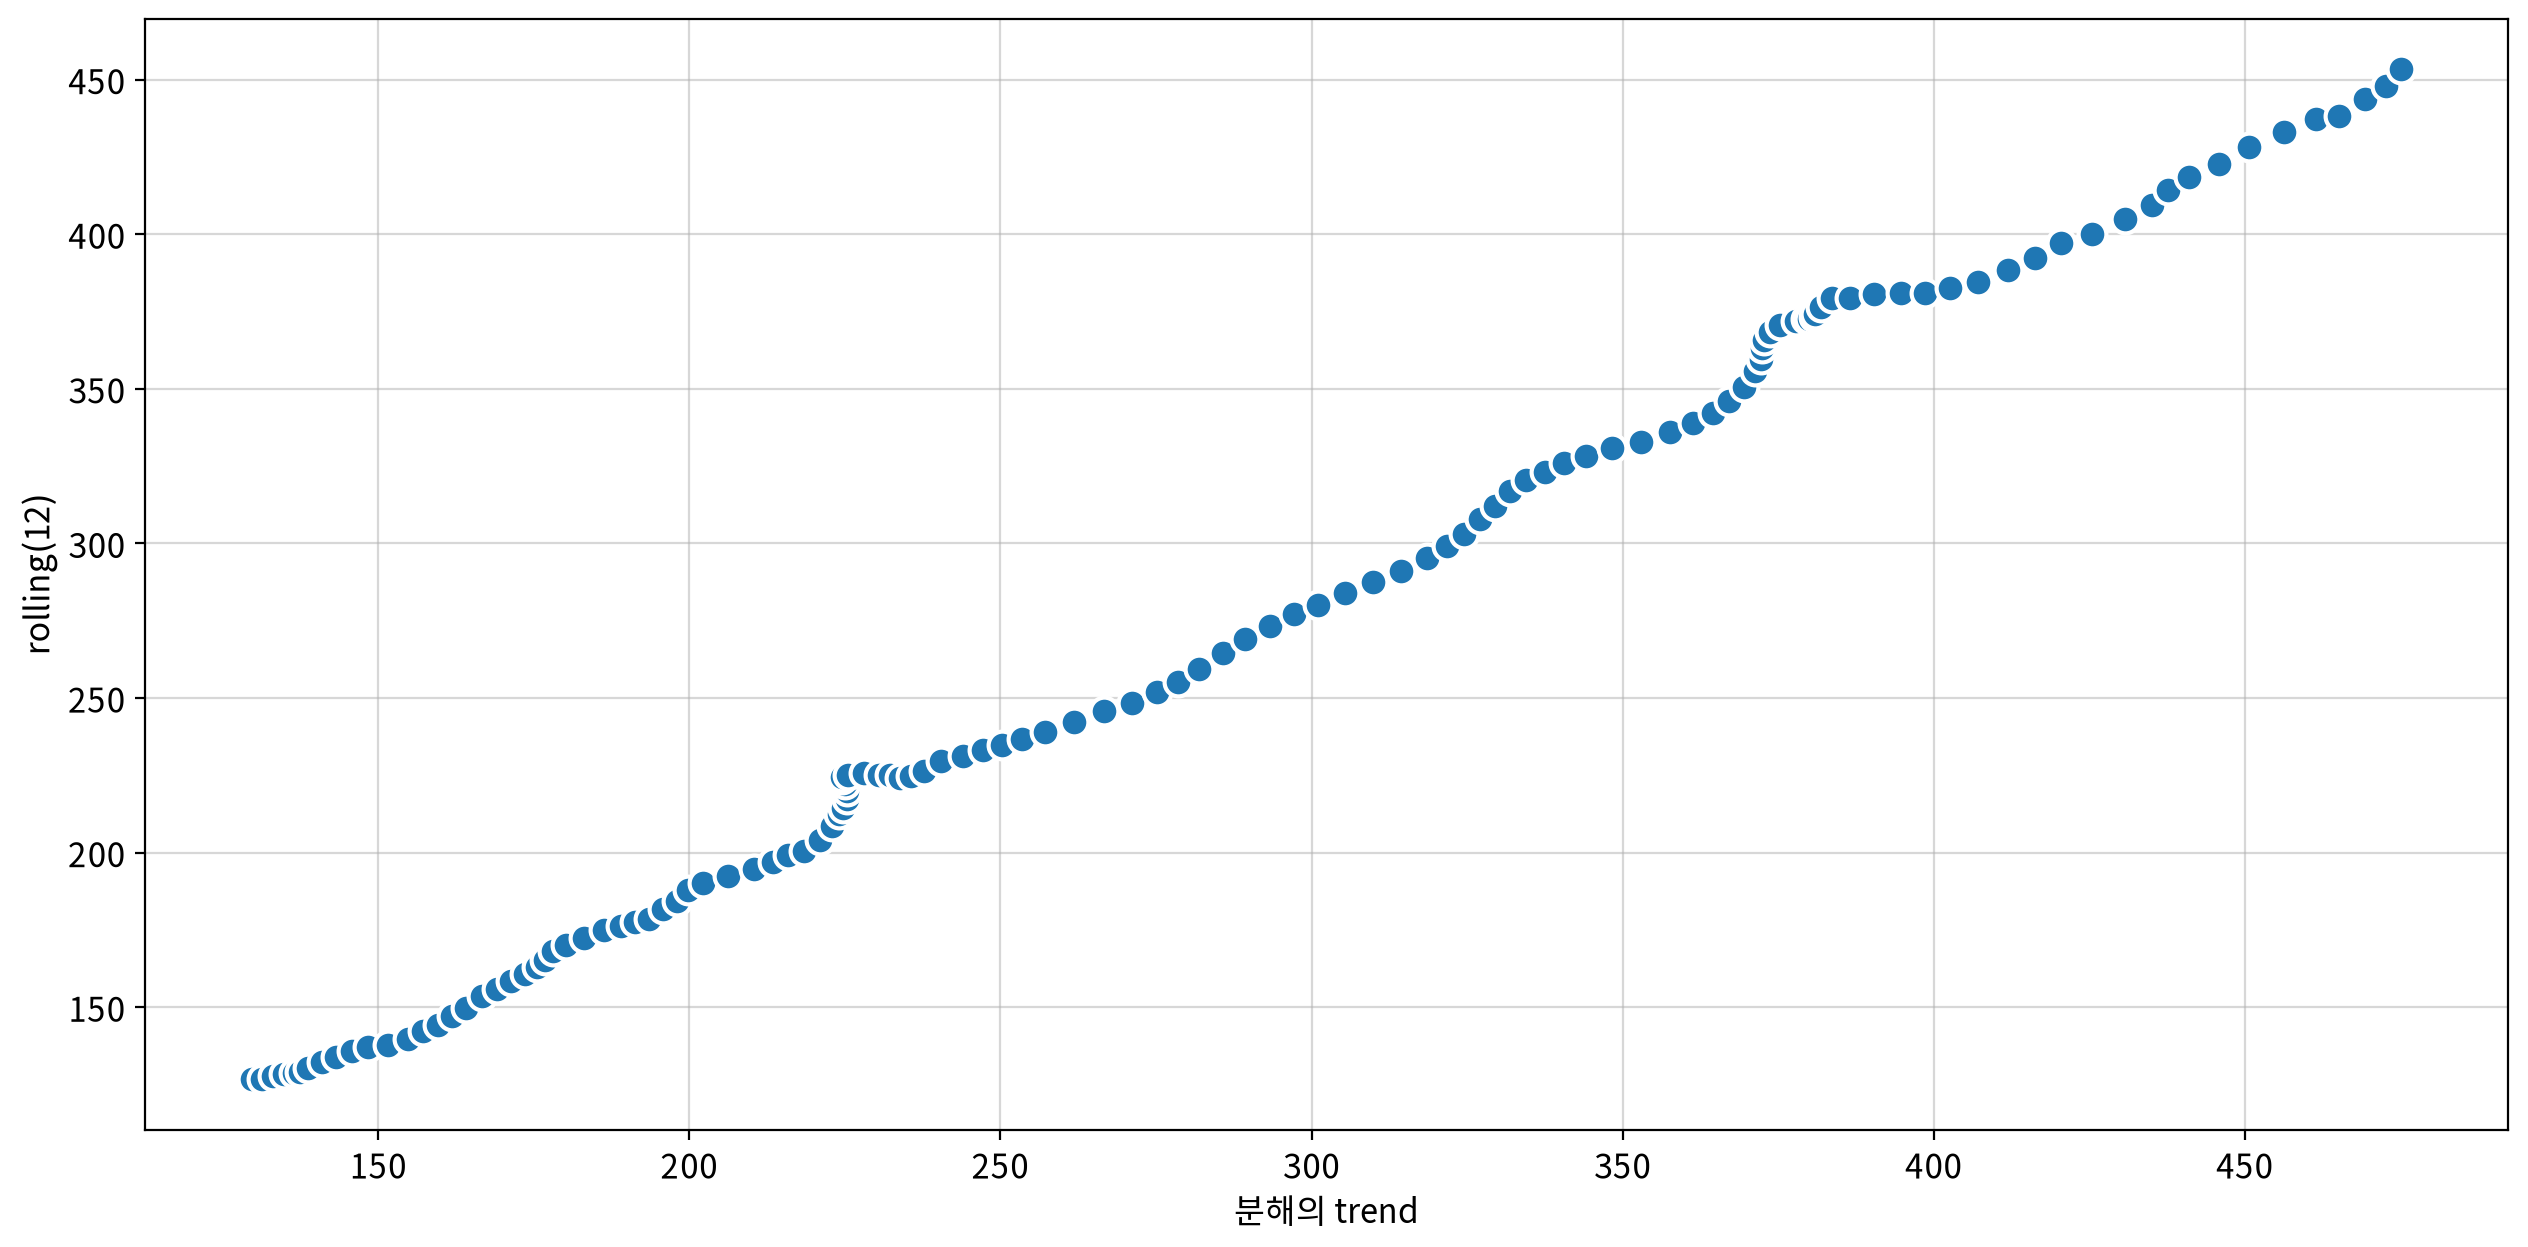

,,method,coef,strength,significant,normality,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
분해의 trend,rolling(12),Spearman,1.000,강함,True,False,False,True,False,False


In [7]:
# 분해가 내놓은 추세 성분과 나란히 놓고 비교한다
check = DataFrame({
    "분해의 trend": sd["trend"],
    "rolling(12)": rolling["이동평균"],
})

# 두 값의 상관계수 확인
my_stats.correlation(check, "분해의 trend", "rolling(12)")

#### 💡 인사이트

- 상관계수가 1이다(p < 0.05).
- 상관이 있는 정도가 아니라 동일한 정보라고 보는 것이 타당하다

### 3. 계절 성분의 특성 (1)

- 계절 성분은 매년 똑같이 반복되므로, **1년치만 뽑아 보면 전체를 알 수 있다.**

In [8]:
# 계절 성분에서 1년치(12개월)만 추출하여 월별로 정리
season = sd["seasonal"].groupby(sd.index.month).first()
season.index.name = "월"
sdf = DataFrame({"계절지수": season.round(4)})

# 계절지수의 평균은 1이어야 한다. (승법 모델 기준)
sdf["평균"] = season.mean().round(4)

# 승법 모델은 원본 = 추세 × 계절 × 잔차 이므로 계절지수는 배수이다.
# 기준점이 1(= 추세와 똑같음)이므로, 1을 빼면 기준에서 얼마나 벗어났는지가 되고,
# ×100 하면 백분율이 된다.
# 즉, 추세 대비 몇 % 증감인지를 의미한다.
sdf["추세 대비"] = ((season - 1) * 100).round(1).astype(str) + "%"

sdf.T

월,1,2,3,4,5,6,7,8,9,10,11,12
계절지수,0.910,0.884,1.007,0.976,0.981,1.113,1.227,1.220,1.060,0.922,0.801,0.899
평균,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
추세 대비,-9.0%,-11.6%,0.7%,-2.4%,-1.9%,11.3%,22.7%,22.0%,6.0%,-7.8%,-19.9%,-10.1%


### 4. 계절 성분의 특성 (2) - 추세 대비 시각화

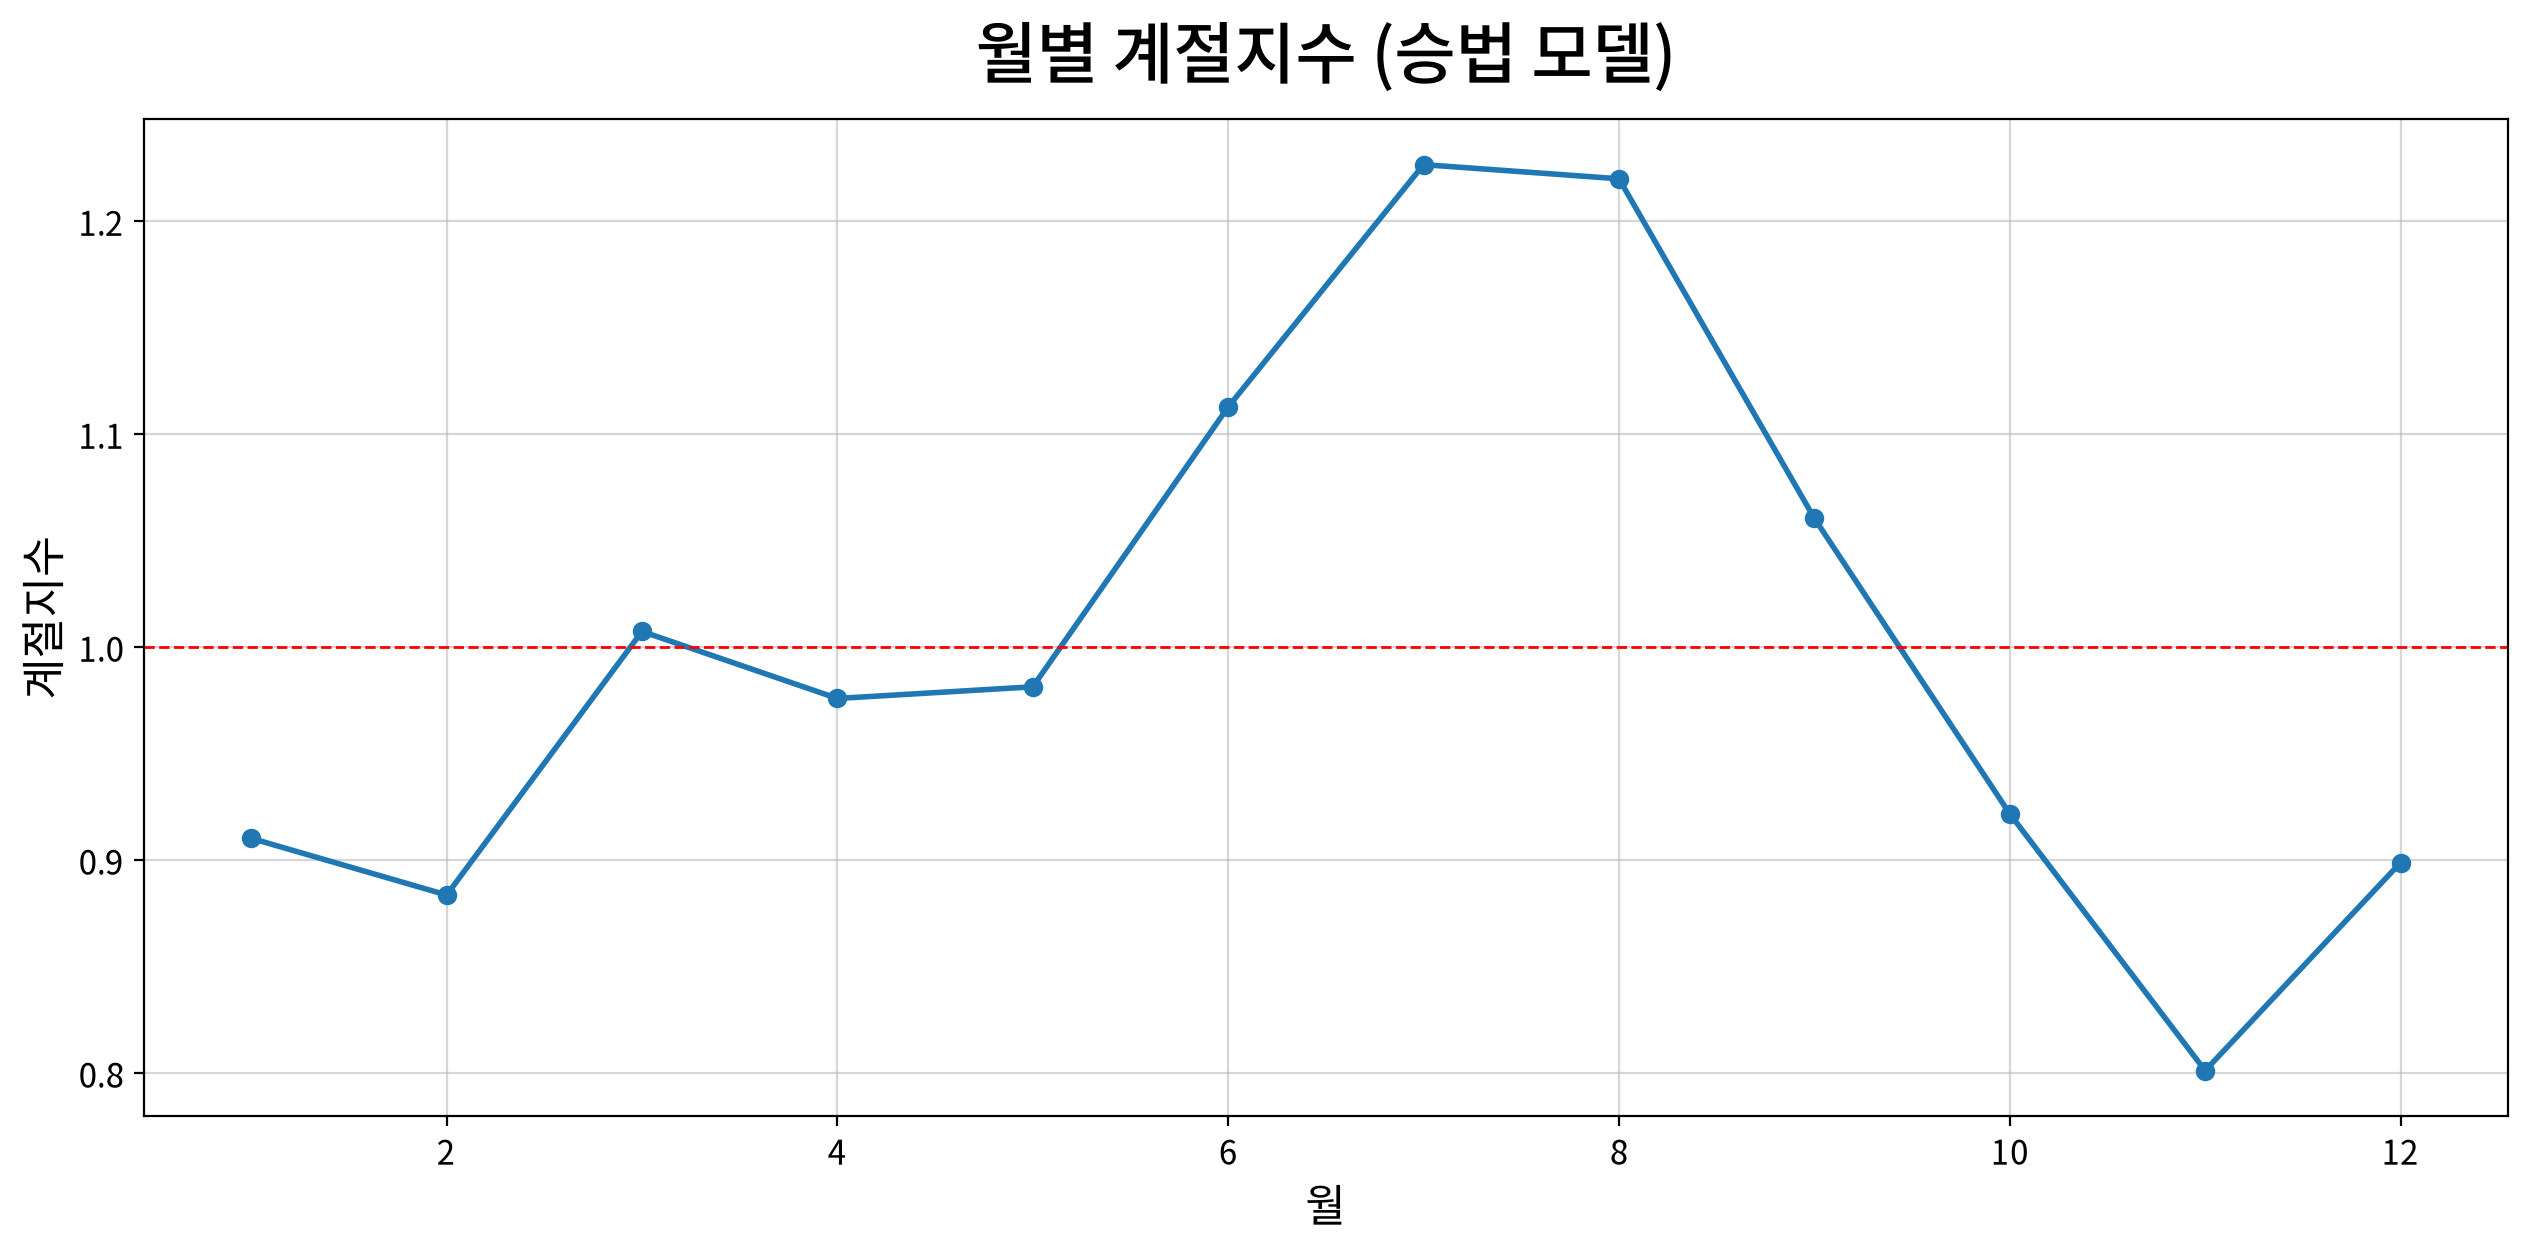

In [9]:
# 그래프 초기화
fig, ax = my_plot.init(title="월별 계절지수 (승법 모델)", 
                       xlabel="월", ylabel="계절지수")

# 캔버스(ax)에 추세 대비를 선 그래프로 표시
my_plot.lineplot(x=season.index, y=season.values, marker="o", ax=ax)

# 승법 모델 기준 평균선(=1)을 표시
ax.axhline(1, color="red", linestyle="--", linewidth=1)

# 그래프 화면 출력
my_plot.show()

#### 💡 인사이트

- **(1) 성수기·비수기 구분**
  - 성수기 : 7월 1.227 · 8월 1.220 · 6월 1.113 · 9월 1.060
  - 비수기 : 11월 0.801 · 2월 0.884 · 12월 0.899 · 1월 0.910 · 10월 0.922
  - 중립 : 3월 1.007 · 5월 0.981 · 4월 0.976
  - 계절 영향 거의 없음 → 증감은 추세·불규칙 요인으로 봐야 함
- **(2) 계절성의 진폭**
  - 1.227 ÷ 0.801 = 1.532배
  - 진폭이 클수록 계절조정 없이는 판단 불가
- **(3) 여름 한 덩어리**
  - 6~9월 넉 달 연속 1.0 초과
  - 스파이크가 아닌 두꺼운 성수기 구조임
- **(4) 인접 달 비율**
  - 계절만으로 생기는 전월 대비 변화량

### 5. 계절조정 시계열 만들기

원본에서 계절 성분을 걷어내면 **계절 요인을 제거한 순수한 움직임**이 남는다.

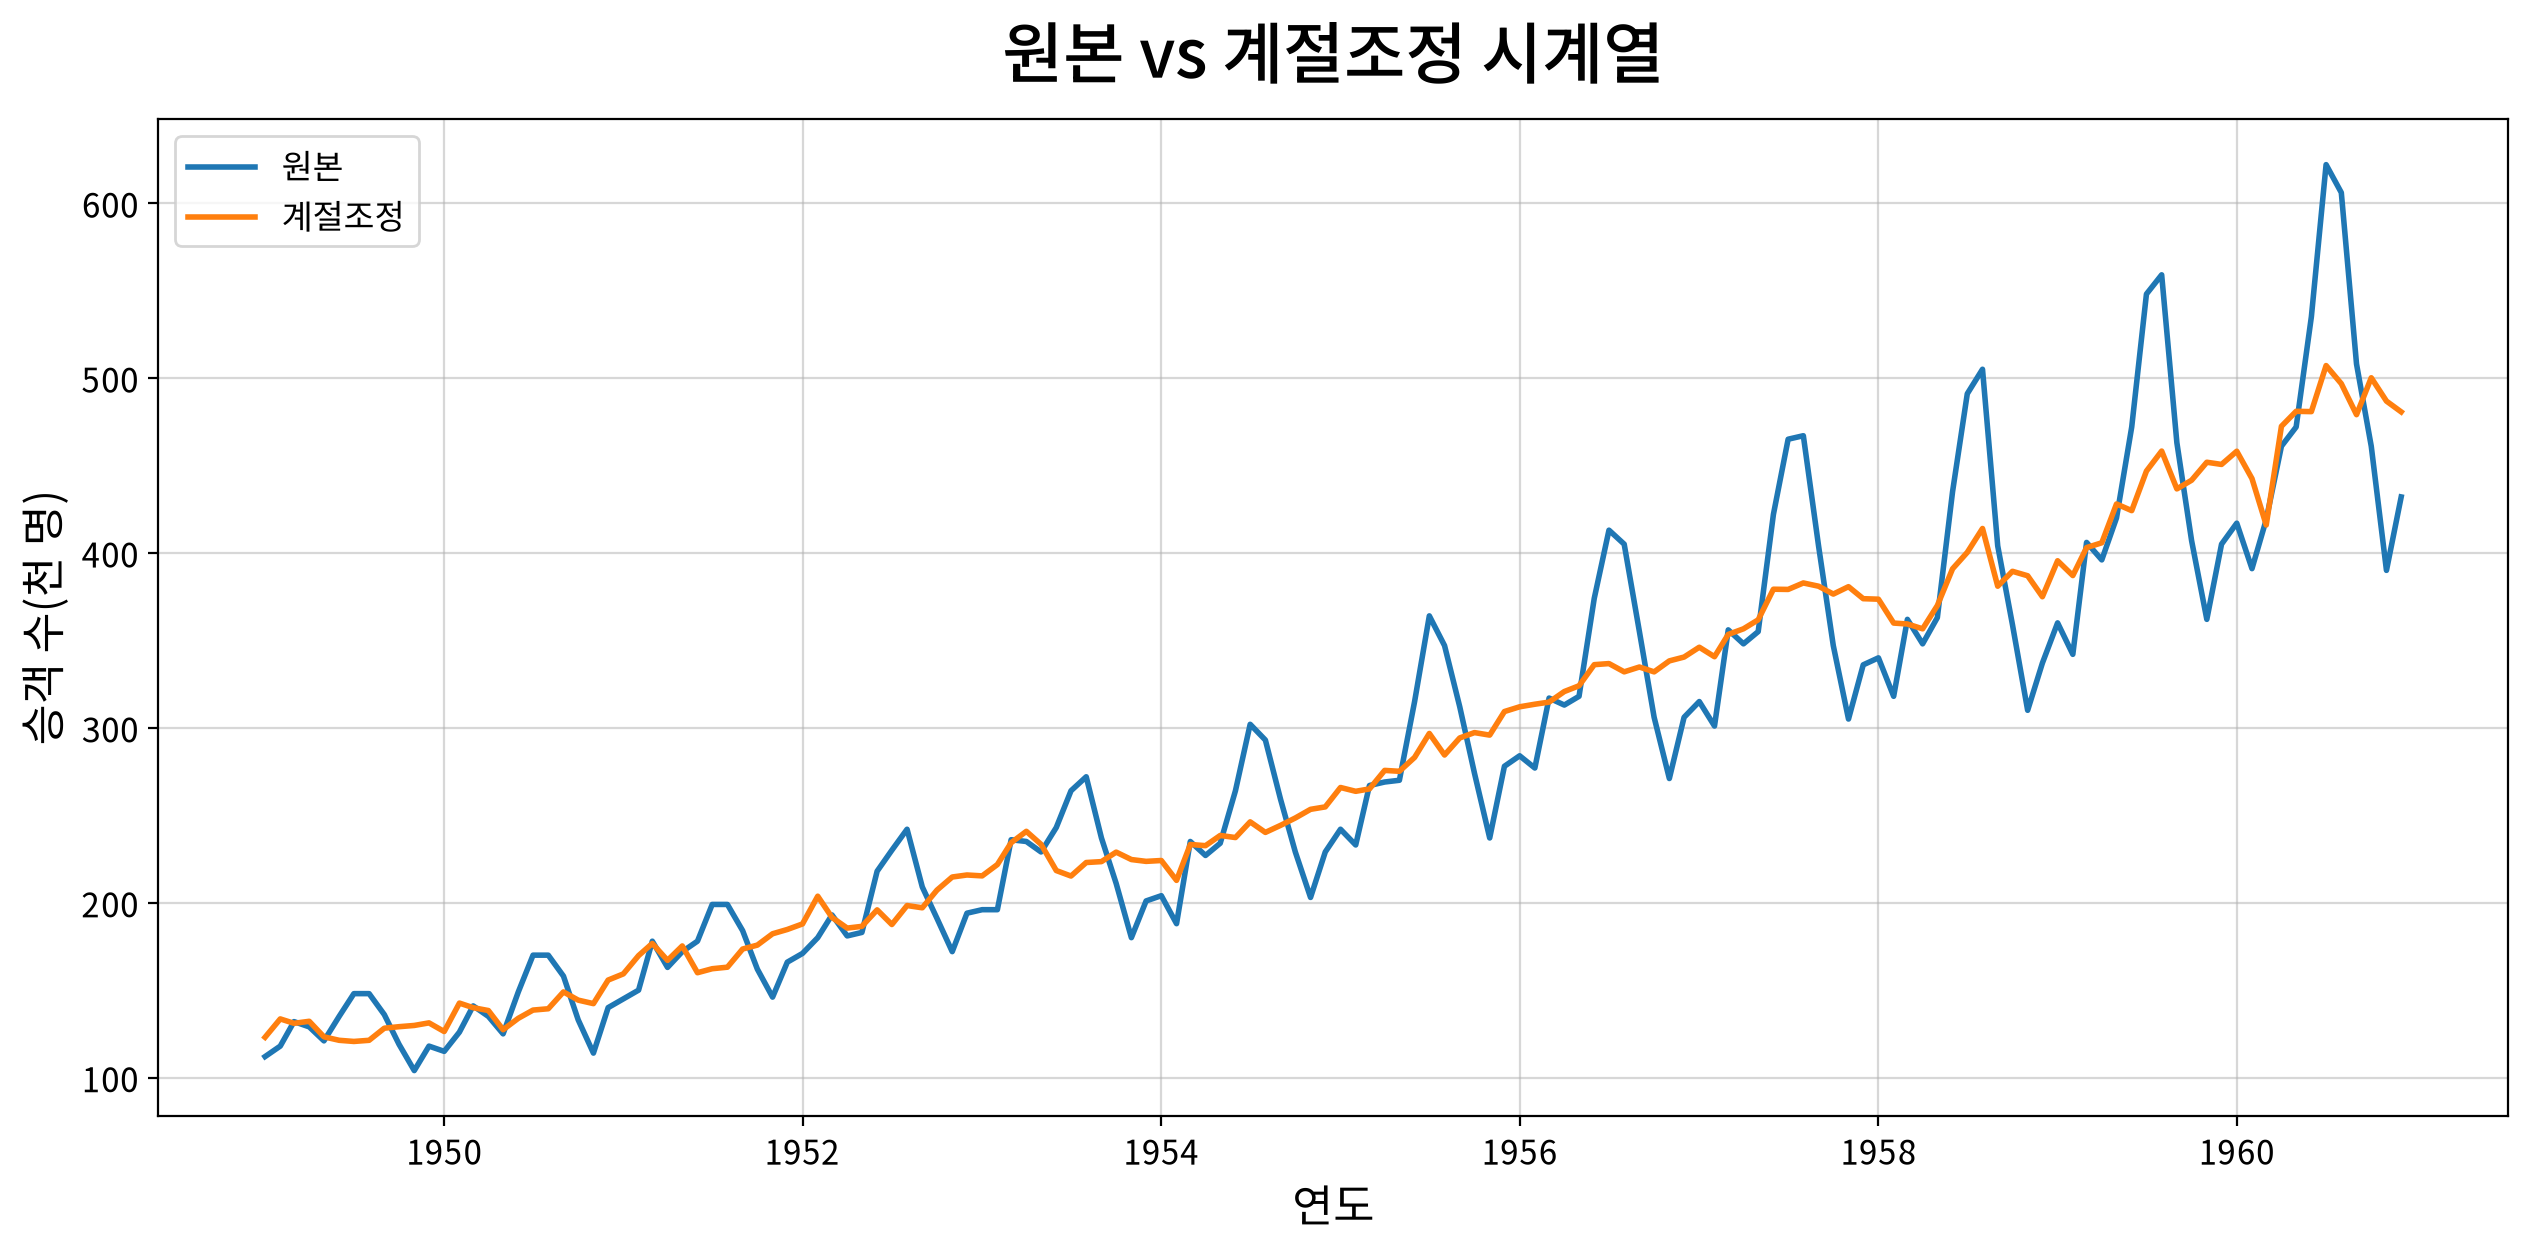

In [10]:
# 승법 모델이므로 나누기로 계절 성분을 제거한다 (가법이면 빼기)
adjusted = sd["original"] / sd["seasonal"]

fig, ax = my_plot.init(title="원본 vs 계절조정 시계열",
                       xlabel="연도", ylabel="승객 수(천 명)")

my_plot.lineplot(x=df.index, y=df["Passengers"], label="원본", ax=ax)
my_plot.lineplot(x=adjusted.index, y=adjusted, label="계절조정", ax=ax)

ax.legend()
my_plot.show()

#### 💡 인사이트

- 계절조정 시계열은 봉우리가 사라졌지만 **이동평균처럼 매끈하지는 않다.**
- 남은 울퉁불퉁함이 바로 **잔차(불규칙 요인)** 다.

> 계절조정 결과에서 갑자기 튀는 지점이 있다면
> 그 시점에 **계절성으로 설명되지 않는 사건**이 있었다는 뜻이다.
> 실무에서 이상 시점을 찾는 표준적인 방법이다.

## #04. 모듈화 기능 확인

### 1. 분해 시계열 생성

결합 방식 자동 판정: multiplicative
관측치 144개 중 추세·잔차가 계산된 구간 132개


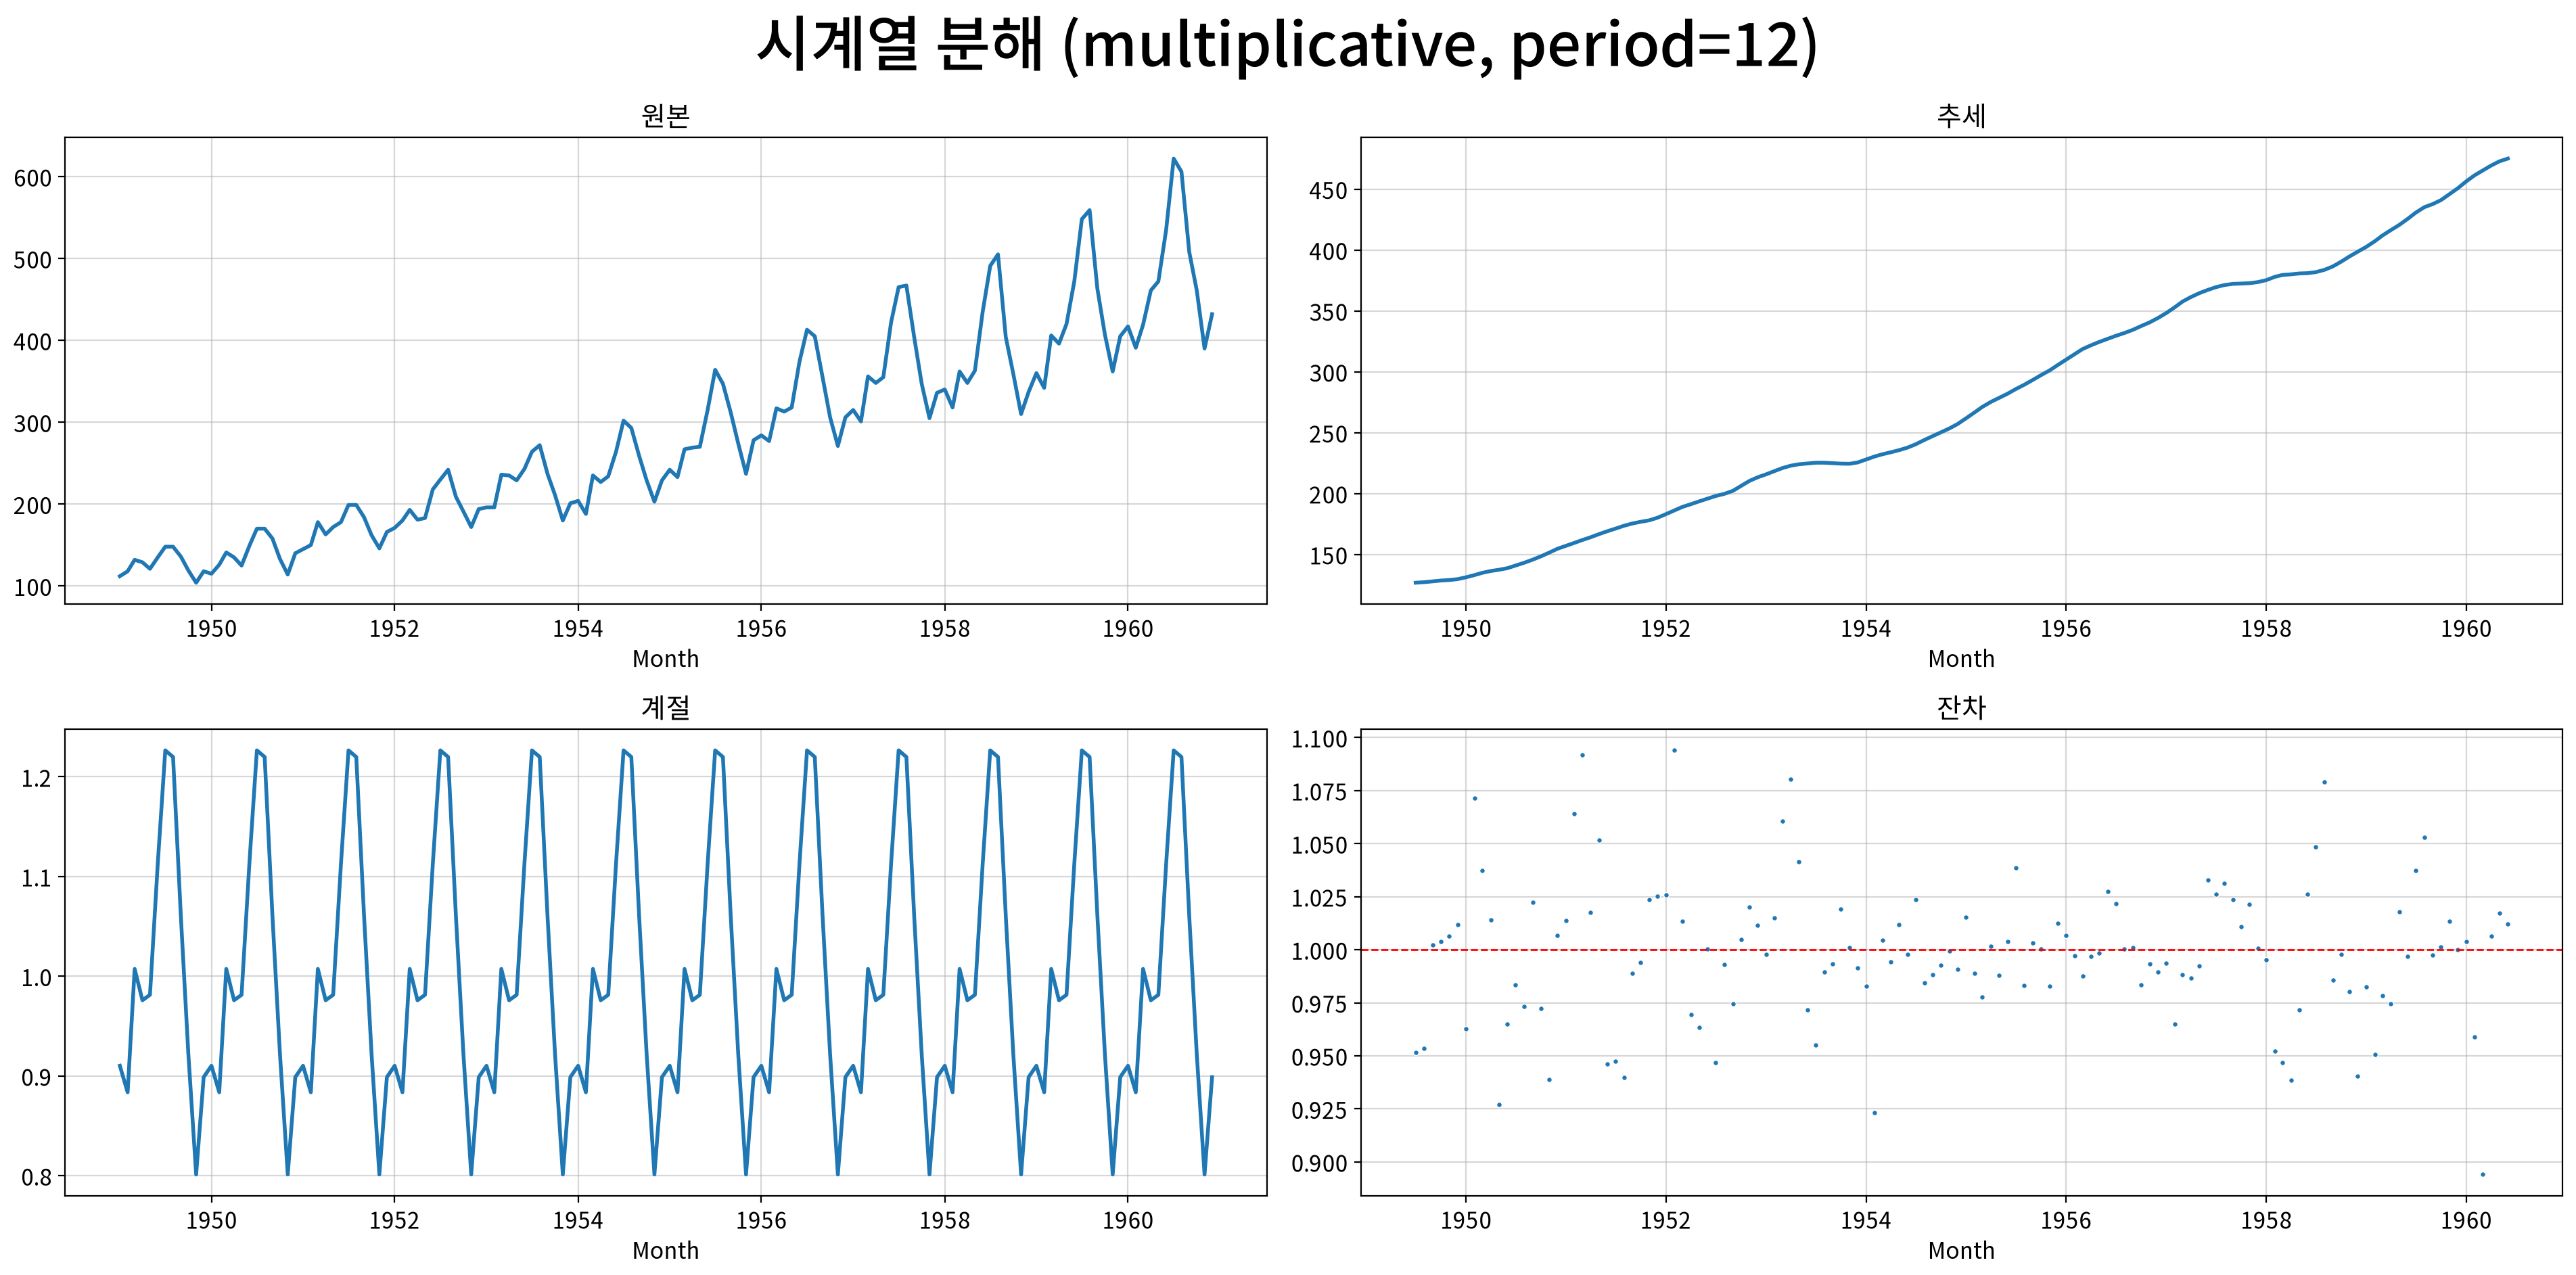

,원본,추세,계절,잔차
Month,,,,
1949-07-01,148.000,126.792,1.227,0.952
1949-08-01,148.000,127.250,1.220,0.953
1949-09-01,136.000,127.958,1.060,1.002


In [11]:
# model 을 주지 않으면 가법/승법을 스스로 판정한다
result = my_ts.decompose(df, 12, "Passengers")

# 표는 화면에 뿌려지지 않고 반환되므로, 보고 싶으면 마지막 줄에 놓는다
result.dropna().head(3)

### 2. 계절지수

결합 방식 : multiplicative
최고 위치 : 7 (1.2266)
최저 위치 : 11 (0.8012)


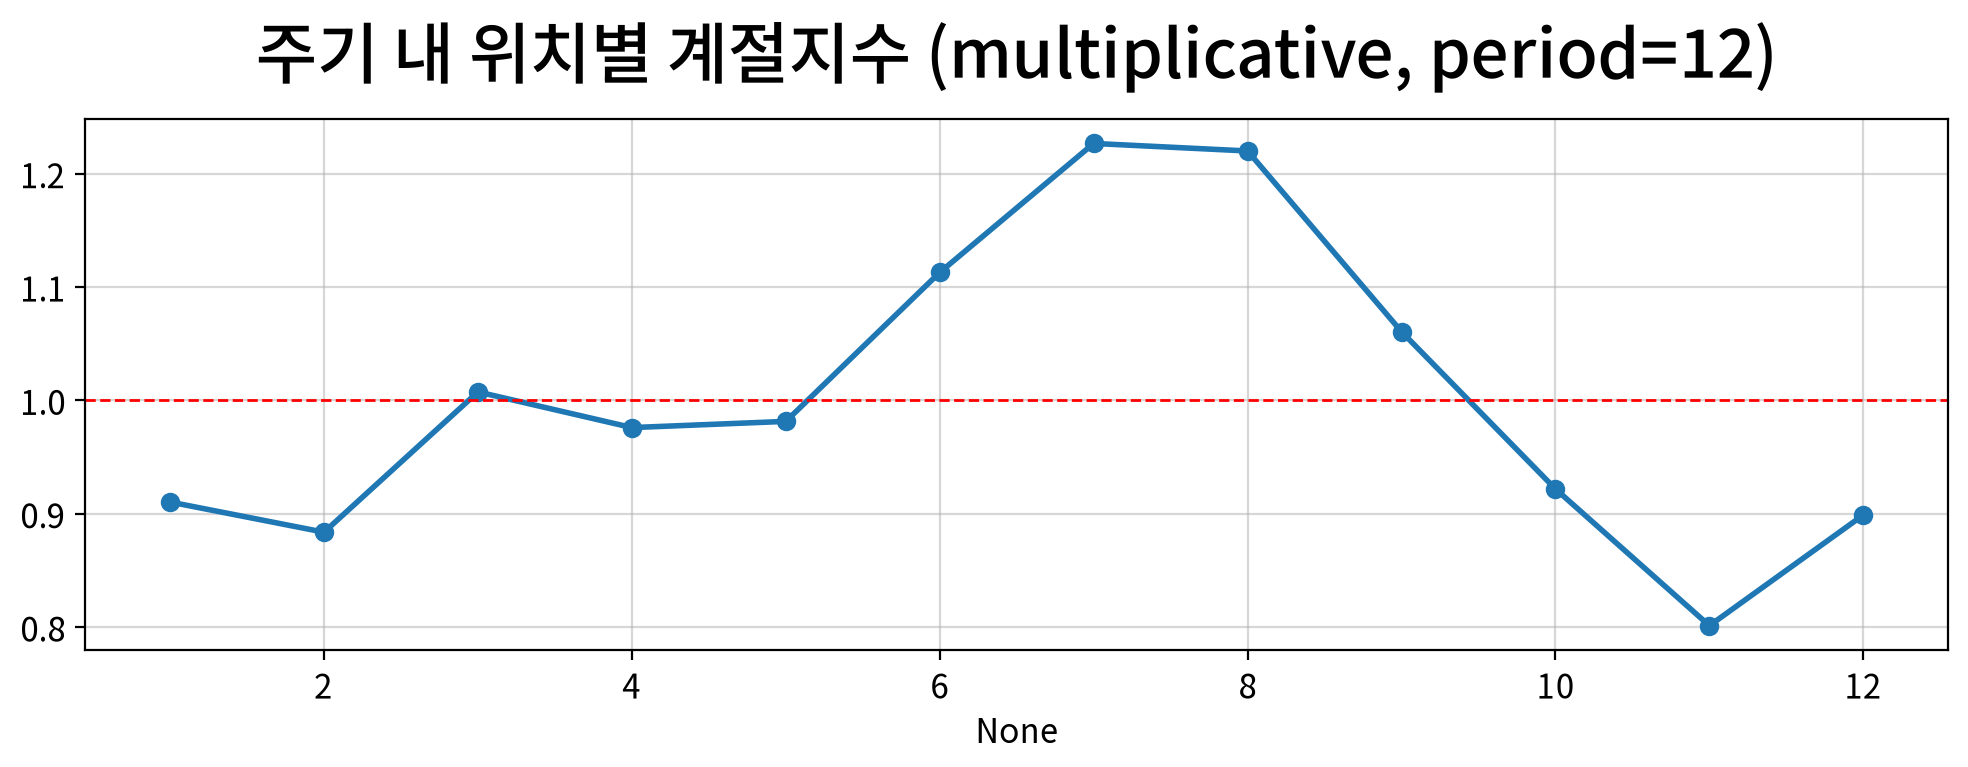

주기 내 위치,1,2,3,4,5,6,7,8,9,10,11,12
계절지수,0.910,0.884,1.007,0.976,0.981,1.113,1.227,1.220,1.060,0.922,0.801,0.899
평균,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
기준 대비(%),-9.000,-11.600,0.700,-2.400,-1.900,11.300,22.700,22.000,6.000,-7.800,-19.900,-10.100


In [12]:
ss = my_ts.report_seasonal(df, 12, "Passengers")
ss.T

### 3. 계절조정

결합 방식: multiplicative (원본 ÷ 계절)


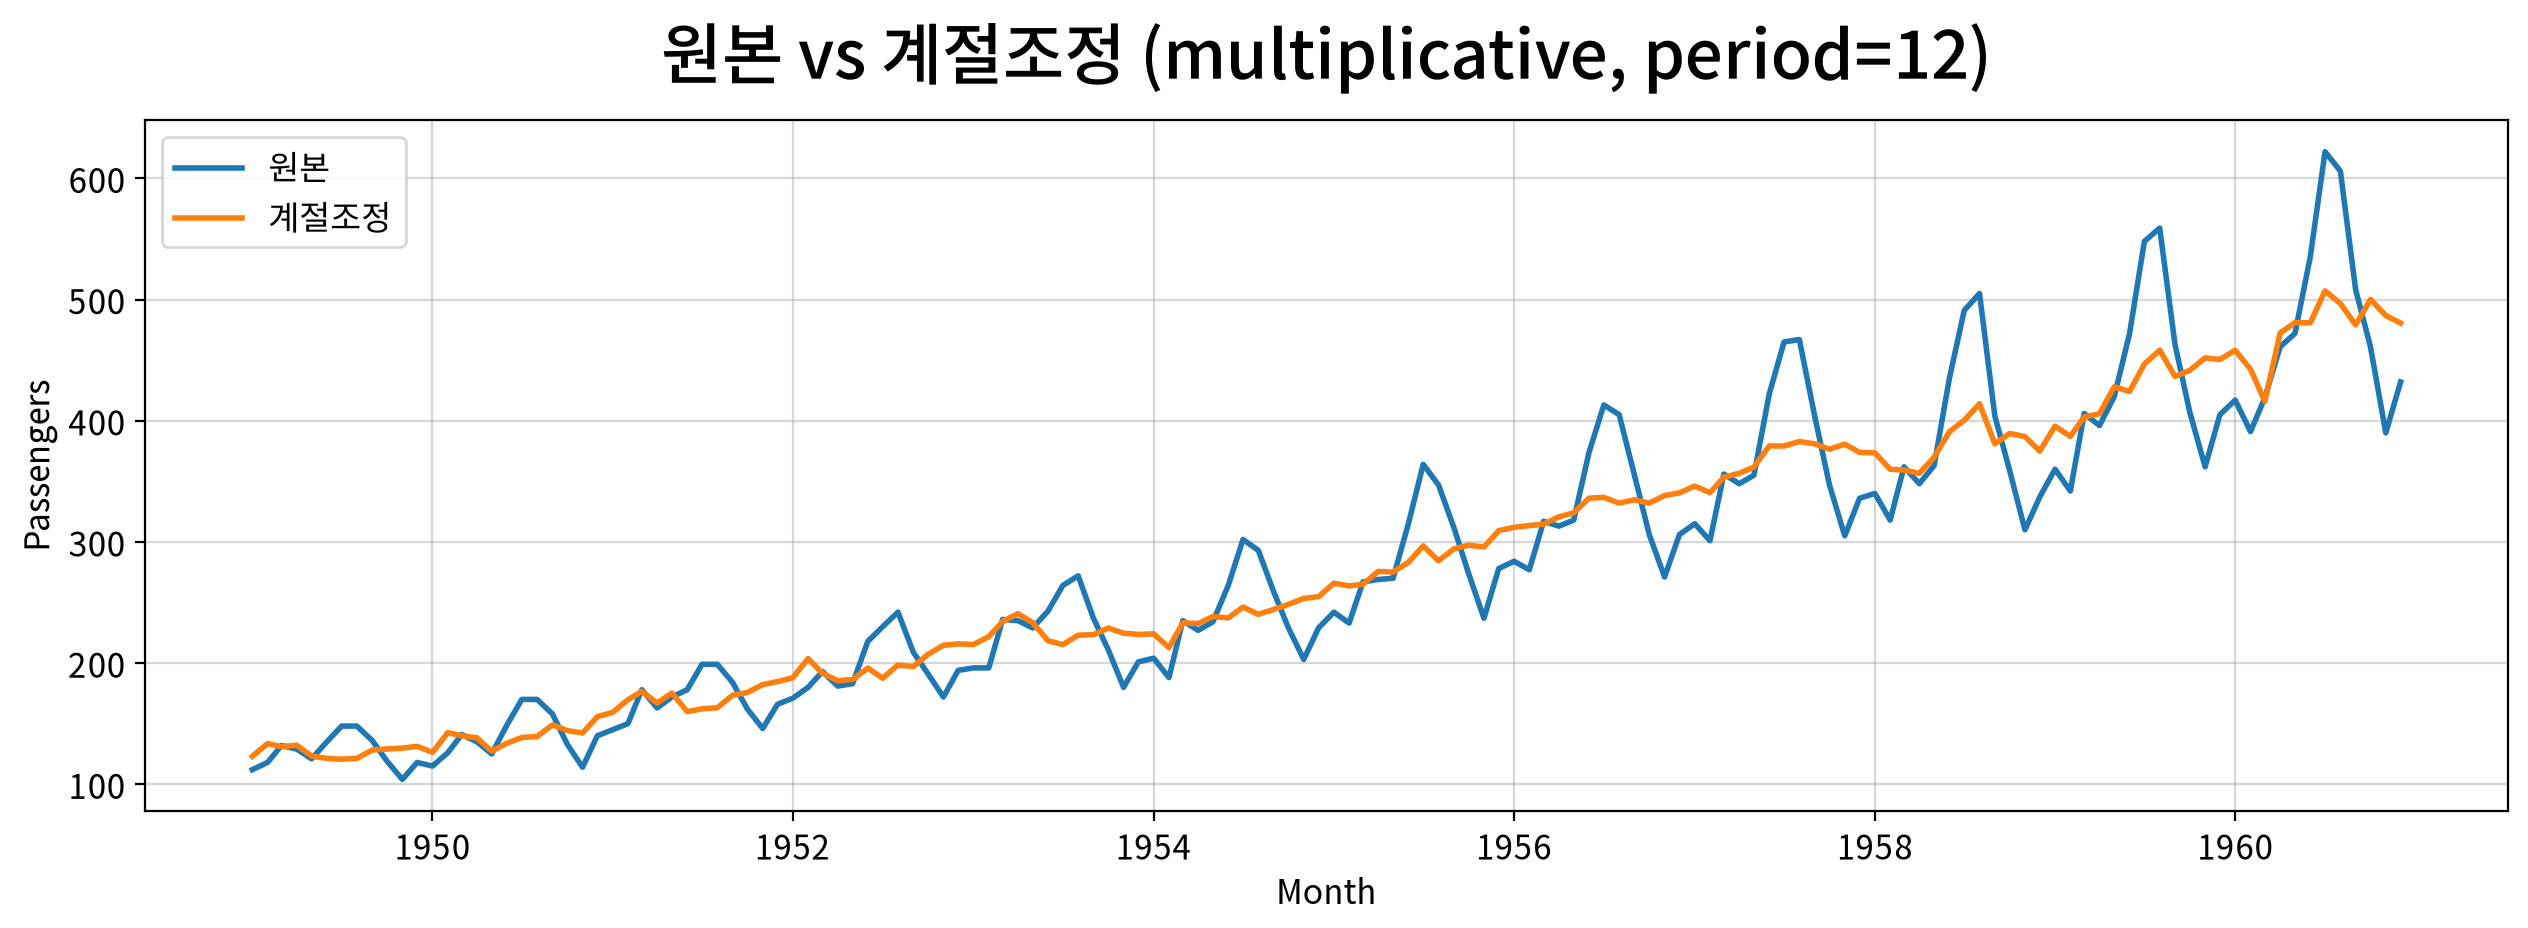

Month
1949-01-01   123.046
1949-02-01   133.541
1949-03-01   131.035
Freq: MS, dtype: float64

In [14]:
adjusted = my_ts.adjust_seasonal(df, 12, "Passengers")
adjusted.head(3)

#### 연습문제. 데이터셋:temperatures_seoul
#### (d= 0, D =1, s = 12)

#### 문제 1. 사무관에게 보여줄 분해 결과를 만들려면 세 성분이 어떤 방식으로 결합되어 있는지부터 정해야한다. 이 자료는 가법과 승법 중 어느 방식으로 판정되나요?
#### 문제 2. "원본 그래프로는 온난화가 안 보인다"는 말을 숫자로 뒷받침해야합니다. 원본의 흔들림을 거의 전부 만들어내는 성분의 표준편차는 얼마인가요?
#### 문제 3. 겨울이 얼마나 추운 쪽으로 끌어내리는지 보여주려 합니다. 1월의 계절지수는 몇 도 인가요?
#### 문제 4. 계절을 걷어낸 그래프를 보고서에 실으려 합니다. 계절요인을 제거한 계열의 표준편차는 얼마인가?
#### 문제 5. 계절을 지우는 다른 방법인 계절차분도 함께 시도했습니다. 계절차분을 적용한 뒤 남는 관측치는 몇개인가?
#### 문제 6. 사무관의 마지막 물음에 답할 차례입니다. 계절 조정과 계절차분 중 시민보고서에 실어야하는 계열은?


In [15]:
# 데이터 불러오기
origin = load_data('temperatures_seoul')

df = my_ts.set_index(origin, "날짜", freq="MS")

print(f"기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m} | {len(df)}개월 | 간격 {df.index.freqstr}")
df.head(3)

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
기간: 1973-07 ~ 2023-08 | 602개월 | 간격 MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323


결합 방식 자동 판정: additive
관측치 602개 중 추세·잔차가 계산된 구간 590개


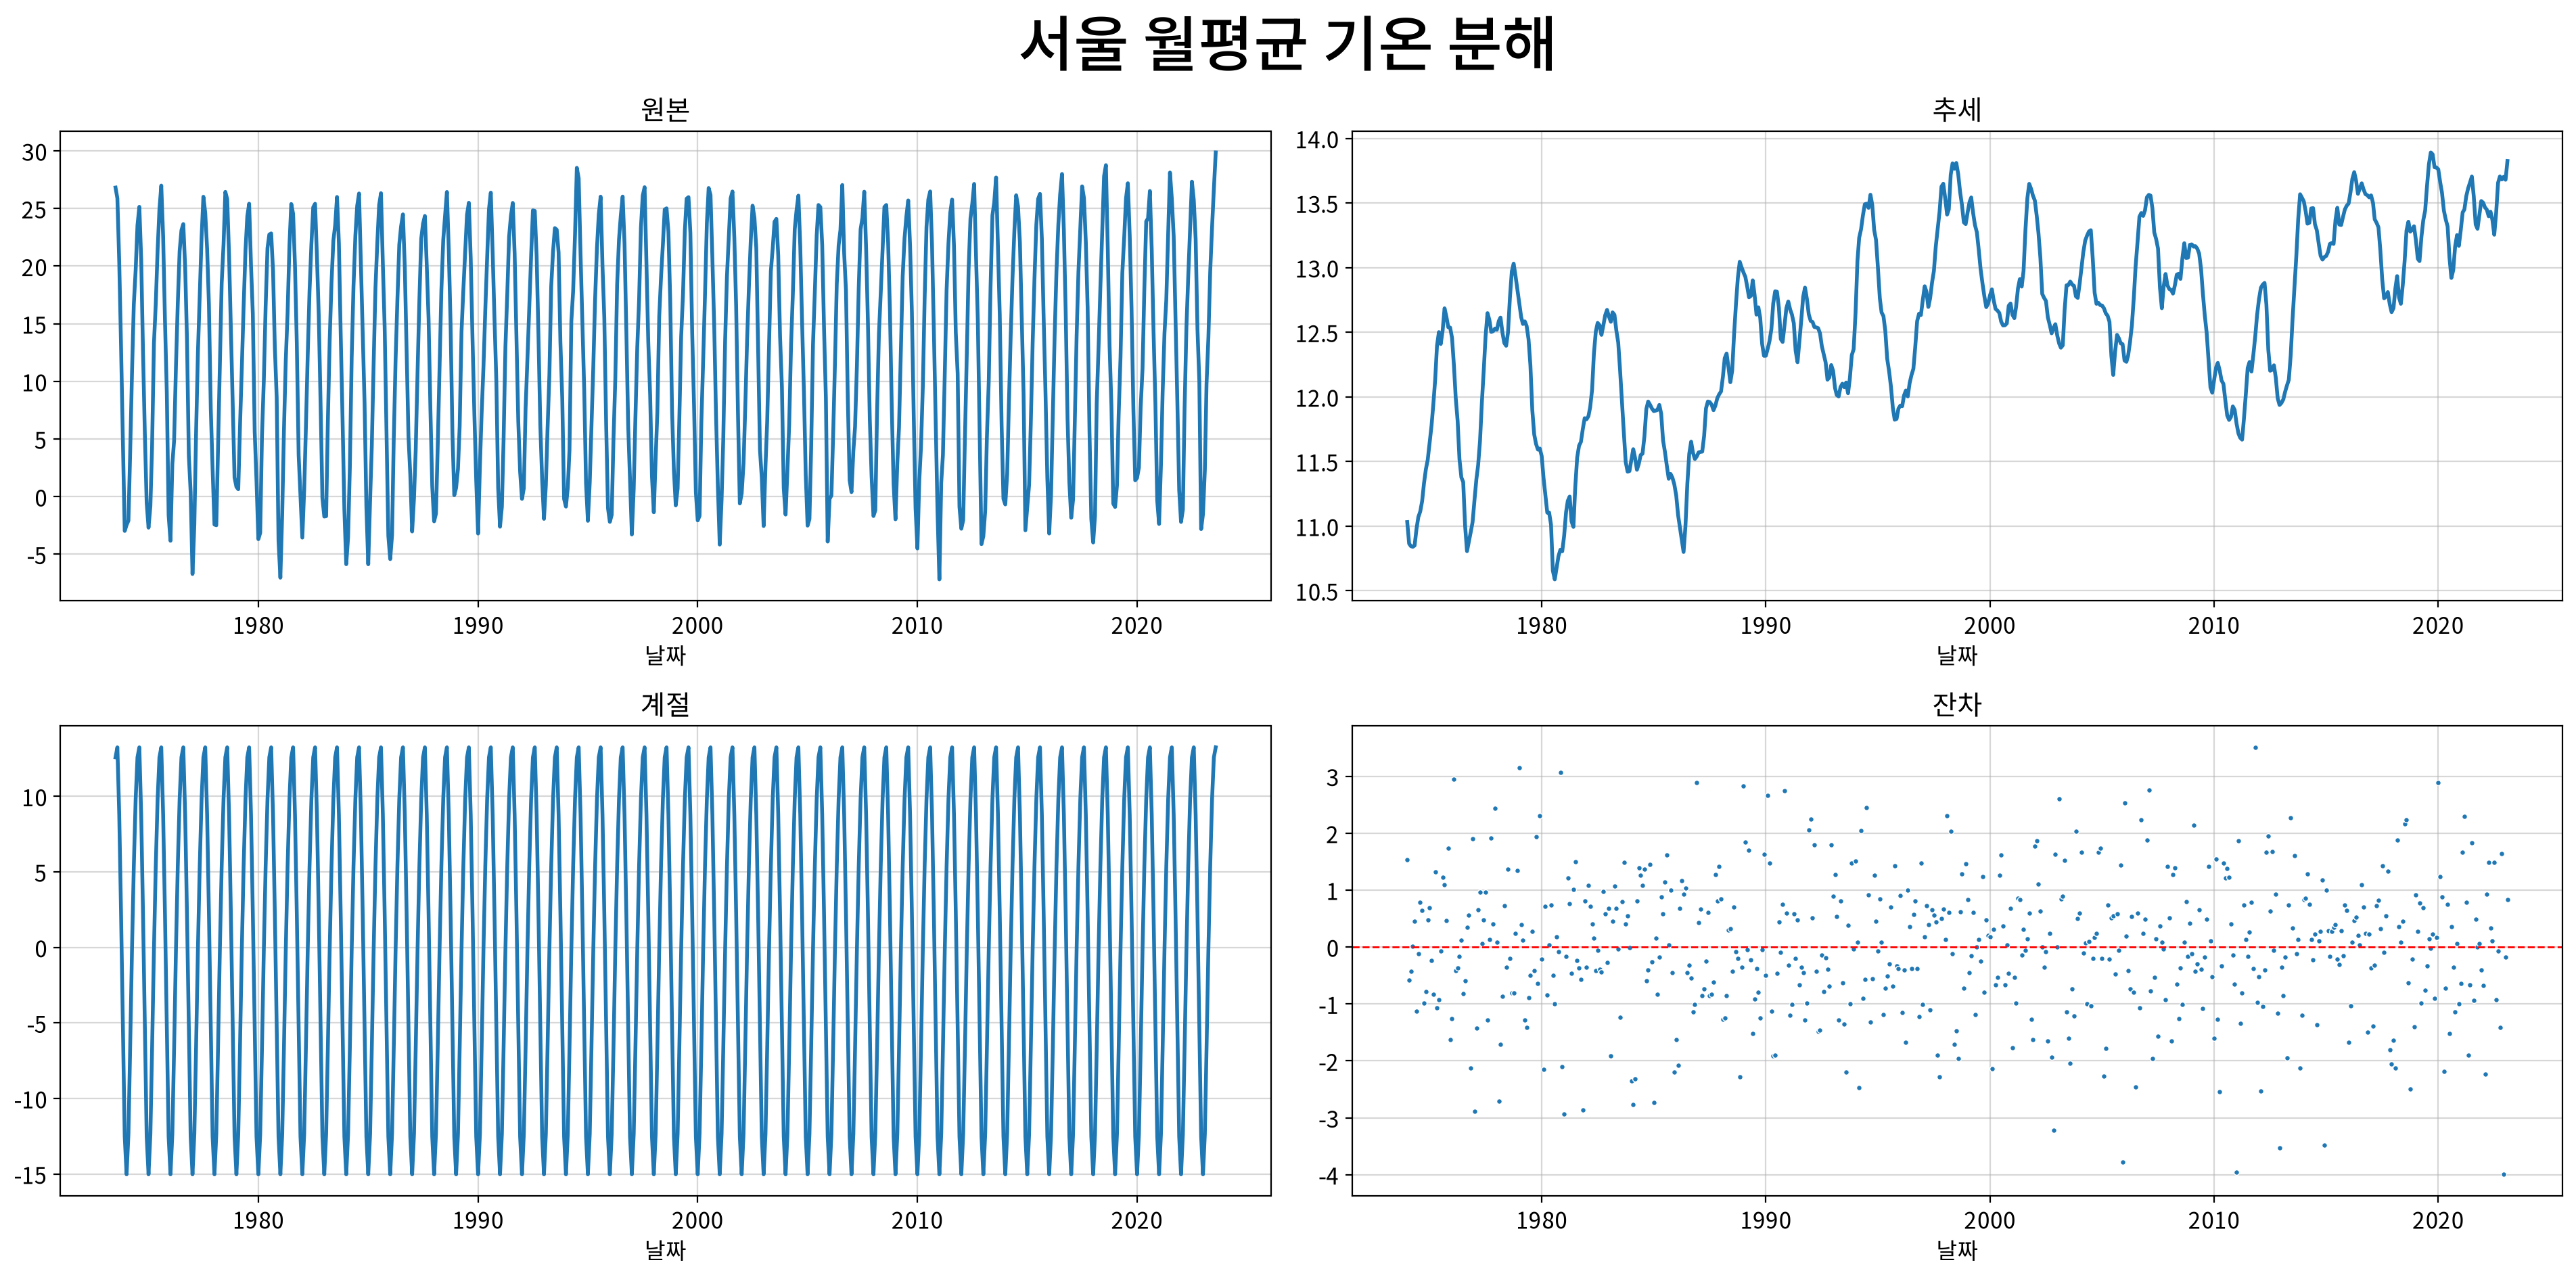

,원본,추세,계절,잔차
날짜,,,,
1974-01-01,-2.458,11.031,-15.024,1.535
1974-02-01,-2.079,10.864,-12.361,-0.582
1974-03-01,3.687,10.845,-6.728,-0.430


In [17]:
sd = my_ts.decompose(df, 12, "평균기온(℃)",
                     title="서울 월평균 기온 분해",
                     width=960, height=480)

sd.dropna().head(3)